In [13]:
# ==============================================================================
# CELL 1: SYSTEM DEPENDENCIES & ENVIRONMENT INSTALLATION
# ==============================================================================
import sys
import subprocess

def install_dependencies():
    """Installs required packages tailored for CPU execution."""
    packages = [
        "transformers",
        "opencv-python",
        "pillow",
        "matplotlib",
        "tqdm",
        "numpy",
        "requests"
    ]
    
    print("[INFO] Validating and installing system environment dependencies...")
    
    # Check and install PyTorch CPU specific build if not present
    try:
        import torch
        print(f"[INFO] PyTorch version found: {torch.__version__}")
    except ImportError:
        print("[INFO] PyTorch not detected. Installing CPU-optimized PyTorch build...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cpu"])

    # Install remaining packages
    for package in packages:
        try:
            __import__(package if package != "opencv-python" else "cv2")
        except ImportError:
            print(f"[INFO] Installing package: {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            
    print("[SUCCESS] Environment fully initialized and verified.")

# Execute installation verification
install_dependencies()

[INFO] Validating and installing system environment dependencies...
[INFO] PyTorch version found: 2.12.1+cpu
[INFO] Installing package: pillow...
[SUCCESS] Environment fully initialized and verified.


In [14]:
# ==============================================================================
# CELL 2: FRAMEWORK IMPORTS & HARDWARE ACCELERATION SPECIFICATION
# ==============================================================================
import os
import json
import time
import csv
from typing import List, Dict, Union, Tuple
from io import BytesIO

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from tqdm import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration

# Configure deterministic execution hardware
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"[ENGINE] CUDA Acceleration Detected. Using hardware target: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("[ENGINE] Apple Silicon MPS Acceleration Detected.")
else:
    device = torch.device("cpu")
    print("[ENGINE] Hardware target initialized to standard CPU mode.")

[ENGINE] Hardware target initialized to standard CPU mode.


In [15]:
class PipelineConfig:
    # Model Repository Parameters
    MODEL_ID: str = "Salesforce/blip-image-captioning-base"
    
    # Image Preprocessing Controls
    TARGET_IMAGE_SIZE: Tuple[int, int] = (384, 384)
    FORCE_ASPECT_RATIO_PADDING: bool = True
    
    # Inference Hyperparameters
    NUM_BEAMS: int = 5
    MAX_OUTPUT_LENGTH: int = 45
    MIN_OUTPUT_LENGTH: int = 10
    REPETITION_PENALTY: float = 1.2
    
    # NEW: Updated Local Path Structure Directories
    RAW_DATA_DIR: str = "./data/raw"
    OUTPUT_DIRECTORY: str = "./caption_outputs"
    EXPORT_JSON_NAME: str = "batch_metadata.json"
    EXPORT_CSV_NAME: str = "batch_metadata.csv"

# Re-verify directory safety structures
os.makedirs(PipelineConfig.OUTPUT_DIRECTORY, exist_ok=True)
os.makedirs(PipelineConfig.RAW_DATA_DIR, exist_ok=True)
print(f"[CONFIG] Systems synced. Drop local test images into: {PipelineConfig.RAW_DATA_DIR}")

[CONFIG] Systems synced. Drop local test images into: ./data/raw


In [16]:
# ==============================================================================
# CELL 4: IMAGE INGESTION & OPENCV PREPROCESSING PIPELINE (SSL BYPASS FIXED)
# ==============================================================================
import urllib3
# Suppress insecure request warnings from using verify=False
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

class ImageIngestionEngine:
    """Handles secure network fetching, file read verification, and spatial adjustments via OpenCV."""
    
    @staticmethod
    def load_from_url(url: str) -> np.ndarray:
        """Fetches an image from a web URL, bypasses SSL verification errors, and returns a BGR matrix."""
        try:
            # Added verify=False to bypass local SSL/TLS certificate mismatches
            response = requests.get(url, timeout=15, verify=False)
            response.raise_for_status()
            
            image_bytes = BytesIO(response.content)
            # Fixed: Changed conversion from 'BGR' to 'RGB' (PIL native standard)
            pil_img = Image.open(image_bytes).convert('RGB')
            
            # Convert RGB array to OpenCV's expected BGR matrix format
            rgb_mat = np.array(pil_img)
            bgr_mat = cv2.cvtColor(rgb_mat, cv2.COLOR_RGB2BGR)
            return bgr_mat
        except Exception as e:
            raise IOError(f"Failed to ingest image sequence from target URL: {url}. Details: {str(e)}")

    @staticmethod
    def load_from_local_path(path: str) -> np.ndarray:
        """Reads a local image file with explicit verification."""
        if not os.path.exists(path):
            raise FileNotFoundError(f"Target path resolved to non-existent entity: {path}")
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"File exists but OpenCV could not decode image: {path}")
        return img

    @classmethod
    def process(cls, source: str, target_size: Tuple[int, int] = (384, 384)) -> Tuple[np.ndarray, Image.Image]:
        """
        Ingests image, standardizes color spaces, and matches the resolution 
        expected by the model.
        
        Returns:
            Tuple[np.ndarray, Image.Image]: (OpenCV BGR Render, PIL RGB Image for Model)
        """
        if source.startswith(('http://', 'https://')):
            bgr_mat = cls.load_from_url(source)
        else:
            bgr_mat = cls.load_from_local_path(source)
            
        # Convert BGR to RGB for Model Compatibility
        rgb_mat = cv2.cvtColor(bgr_mat, cv2.COLOR_BGR2RGB)
        
        # Resize using cubic interpolation for higher visual fidelity
        resized_rgb = cv2.resize(rgb_mat, target_size, interpolation=cv2.INTER_CUBIC)
        
        # Build PIL container for HuggingFace Processor compatibility
        pil_image = Image.fromarray(resized_rgb)
        
        return bgr_mat, pil_image

# Unit test the ingestion engine with a placeholder item
try:
    mock_url = "https://images.cocodataset.org/val2017/000000039713.jpg"
    raw_cv, model_pil = ImageIngestionEngine.process(mock_url, PipelineConfig.TARGET_IMAGE_SIZE)
    print(f"[TEST SUCCESS] Preprocessing works. Matrix Resolution: {raw_cv.shape} | PIL Size: {model_pil.size}")
except Exception as e:
    print(f"[TEST FAILURE] Image Ingestion component verification failed: {e}")

[TEST FAILURE] Image Ingestion component verification failed: Failed to ingest image sequence from target URL: https://images.cocodataset.org/val2017/000000039713.jpg. Details: 404 Client Error: Not Found for url: https://images.cocodataset.org/val2017/000000039713.jpg


In [17]:
# ==============================================================================
# CELL 5: VISION-LANGUAGE MODEL INFERENCE CORE
# ==============================================================================

class ModelOrchestrationCore:
    """Manages model memory loading, preprocessing, and token generation loops."""
    
    def __init__(self, config: PipelineConfig, execution_device: torch.device):
        self.config = config
        self.device = execution_device
        self.processor = None
        self.model = None
        self.load_model()

    def load_model(self):
        """Downloads or retrieves cached baseline transformer configurations."""
        print(f"[MODEL] Loading model artifacts for: {self.config.MODEL_ID} onto execution core...")
        try:
            self.processor = BlipProcessor.from_pretrained(self.config.MODEL_ID)
            self.model = BlipForConditionalGeneration.from_pretrained(self.config.MODEL_ID).to(self.device)
            print("[MODEL] Complete architecture successfully loaded into memory target device.")
        except Exception as e:
            raise RuntimeError(f"Critical architecture allocation failure: {str(e)}")

    def generate_caption(self, image: Image.Image, prompt_modifier: str = "") -> str:
        """
        Processes image inputs and decodes the model's output tokens into a natural sentence.
        
        Args:
            image (Image.Image): Preprocessed RGB PIL Container.
            prompt_modifier (str): Prefix tokens to guide the style of the caption.
        """
        if self.model is None or self.processor is None:
            raise ValueError("Inference attempted while assets were unallocated.")
            
        # Build tensor shapes
        if prompt_modifier:
            inputs = self.processor(images=image, text=prompt_modifier, return_tensors="pt").to(self.device)
        else:
            inputs = self.processor(images=image, return_tensors="pt").to(self.device)
            
        # Compute generation sequence parameters
        with torch.no_grad():
            output_tokens = self.model.generate(
                **inputs,
                max_length=self.config.MAX_OUTPUT_LENGTH,
                min_length=self.config.MIN_OUTPUT_LENGTH,
                num_beams=self.config.NUM_BEAMS,
                repetition_penalty=self.config.REPETITION_PENALTY
            )
            
        # Clear out structural token paddings
        caption = self.processor.decode(output_tokens[0], skip_special_tokens=True)
        return caption.strip()

# Initialize global engine instance
orchestrator = ModelOrchestrationCore(PipelineConfig(), device)

[MODEL] Loading model artifacts for: Salesforce/blip-image-captioning-base onto execution core...


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 9923.40it/s]


[MODEL] Complete architecture successfully loaded into memory target device.


In [18]:
# ==============================================================================
# CELL 6: LINGUISTIC REFINE ENGINE & CUSTOM STYLE FORMATTING
# ==============================================================================

class CaptionRefinementEngine:
    """
    Polishes raw structural descriptions.
    Can be easily connected to an LLM API (like OpenAI/Ollama) down the road.
    """
    
    @staticmethod
    def apply_style(raw_caption: str, style_mode: str) -> str:
        """
        Applies functional linguistic transformation rules based on the chosen style.
        """
        if not raw_caption:
            return "Fallback Caption: Asset analysis yielded clean background state."
            
        # Standard cleaning
        clean_caption = raw_caption.capitalize()
        
        # Rule-based formatting transformations
        style_mappings = {
            "verbose": f"A comprehensive scene analysis captures {clean_caption[0].lower()}{clean_caption[1:]}.",
            "social_media": f"✨ Capture the moment: {clean_caption} #AIVision #Inference",
            "journalistic": f"Observed Environment Log: {clean_caption}.",
            "minimalist": clean_caption
        }
        
        return style_mappings.get(style_mode.lower(), clean_caption)

    @staticmethod
    def get_fallback_caption() -> str:
        """Return a safe fallback option if inference encounters an issue."""
        return "System Notification: Image feature map extraction completed without generation tokens."

In [19]:
# ==============================================================================
# CELL 7: COMPLETE PIPELINE MANAGER INTERFACE
# ==============================================================================

class ImageCaptioningPipeline:
    """Unified entry point that wraps ingestion, inference, styling, and data saving."""
    
    def __init__(self, config: PipelineConfig, core_orchestrator: ModelOrchestrationCore):
        self.config = config
        self.orchestrator = core_orchestrator

    def execute_single(self, source: str, style: str = "minimalist", prompt: str = "") -> Dict[str, str]:
        """Runs one image through the entire pipeline and returns the output metadata."""
        start_time = time.time()
        try:
            # 1. Image Ingestion and Preprocessing via OpenCV
            bgr_mat, model_pil = ImageIngestionEngine.process(source, self.config.TARGET_IMAGE_SIZE)
            
            # 2. Main Inference Loop
            raw_caption = self.orchestrator.generate_caption(model_pil, prompt_modifier=prompt)
            
            # 3. Post-Processing & Styling
            refined_caption = CaptionRefinementEngine.apply_style(raw_caption, style)
            
            latency = time.time() - start_time
            
            return {
                "source": source,
                "status": "SUCCESS",
                "raw_caption": raw_caption,
                "refined_caption": refined_caption,
                "latency_seconds": f"{latency:.3f}"
            }
            
        except Exception as e:
            latency = time.time() - start_time
            return {
                "source": source,
                "status": "FAILED",
                "raw_caption": "",
                "refined_caption": CaptionRefinementEngine.get_fallback_caption(),
                "error_log": str(e),
                "latency_seconds": f"{latency:.3f}"
            }

    def execute_batch(self, sources: List[str], style: str = "minimalist") -> List[Dict[str, str]]:
        """Processes multiple images sequentially with a progress tracking bar."""
        results = []
        print(f"[BATCH] Commencing queue processing for {len(sources)} items...")
        
        for item in tqdm(sources, desc="Pipeline Processing Batch"):
            res = self.execute_single(item, style=style)
            results.append(res)
            
        self._export_metadata(results)
        return results

    def _export_metadata(self, operational_records: List[Dict[str, str]]):
        """Saves batch execution logs to disk in JSON and CSV formats."""
        json_path = os.path.join(self.config.OUTPUT_DIRECTORY, self.config.EXPORT_JSON_NAME)
        csv_path = os.path.join(self.config.OUTPUT_DIRECTORY, self.config.EXPORT_CSV_NAME)
        
        # Write out to JSON
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(operational_records, f, indent=4, ensure_ascii=False)
            
        # Write out to CSV
        if operational_records:
            keys = operational_records[0].keys()
            with open(csv_path, 'w', newline='', encoding='utf-8') as f:
                dict_writer = csv.DictWriter(f, fieldnames=keys)
                dict_writer.writeheader()
                dict_writer.writerows(operational_records)
                
        print(f"[EXPORT COMPLETED] Matrix logs preserved to destination folder: {self.config.OUTPUT_DIRECTORY}")

# Create an instance of our complete system pipeline
pipeline = ImageCaptioningPipeline(PipelineConfig(), orchestrator)

In [20]:
# ==============================================================================
# CELL 8: LIVE VERIFICATION & VISUALIZATION WORKSPACE
# ==============================================================================

def display_pipeline_output(execution_result: Dict[str, str]):
    """Renders the image alongside its generated descriptions."""
    if execution_result["status"] == "FAILED":
        print(f"❌ Execution Failure for Source: {execution_result['source']}")
        print(f"Reason: {execution_result.get('error_log')}")
        return

    # Read image matrix via OpenCV to render in the notebook UI
    source = execution_result["source"]
    try:
        if source.startswith(('http://', 'https://')):
            res = requests.get(source, timeout=10)
            img_arr = np.asarray(bytearray(res.content), dtype=np.uint8)
            bgr = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
        else:
            bgr = cv2.imread(source)
            
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        
        # Plotting layout
        plt.figure(figsize=(10, 7))
        plt.imshow(rgb)
        plt.axis('off')
        
        # Format title text box display
        title_display = (
            f"Raw Generated Caption:\n\"{execution_result['raw_caption']}\"\n\n"
            f"Styled Caption ({PipelineConfig.EXPORT_CSV_NAME}):\n\"{execution_result['refined_caption']}\"\n\n"
            f"Inference Latency: {execution_result['latency_seconds']} seconds"
        )
        
        plt.title(title_display, loc='left', fontsize=11, color='darkblue', fontweight='semibold', pad=15)
        plt.show()
        
    except Exception as e:
        print(f"System Canvas Draw Error: Could not display visual frame. {e}")

# Define test sample dataset assets
# Update this variable in your last cell (Cell 8)
sample_image_dataset = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Savannah_Cat_portrait.jpg/800px-Savannah_Cat_portrait.jpg",  # A beautiful cat portrait
    "https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/gantry.jpg"                                           # An industrial crane/dock scene
]

# Run single inference execution loop with custom style
print("\n--- TEST CASE 1: SINGLE MODEL INFERENCE WITH VERBOSITY MODIFIER ---")
single_run = pipeline.execute_single(sample_image_dataset[0], style="verbose")
display_pipeline_output(single_run)

# Run full batch processing framework
print("\n--- TEST CASE 2: BATCH PRODUCTION PIPELINE RUN & EXPORT ---")
batch_runs = pipeline.execute_batch(sample_image_dataset, style="social_media")

# Review final outputs stored on disk
print(f"\nExecution Metadata saved to disk. To view results, read: {PipelineConfig.OUTPUT_DIRECTORY}/{PipelineConfig.EXPORT_JSON_NAME}")


--- TEST CASE 1: SINGLE MODEL INFERENCE WITH VERBOSITY MODIFIER ---
❌ Execution Failure for Source: https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Savannah_Cat_portrait.jpg/800px-Savannah_Cat_portrait.jpg
Reason: Failed to ingest image sequence from target URL: https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Savannah_Cat_portrait.jpg/800px-Savannah_Cat_portrait.jpg. Details: 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Savannah_Cat_portrait.jpg/800px-Savannah_Cat_portrait.jpg

--- TEST CASE 2: BATCH PRODUCTION PIPELINE RUN & EXPORT ---
[BATCH] Commencing queue processing for 2 items...


Pipeline Processing Batch: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it]

[EXPORT COMPLETED] Matrix logs preserved to destination folder: ./caption_outputs

Execution Metadata saved to disk. To view results, read: ./caption_outputs/batch_metadata.json


[LOCAL TASK] Discovered 1 local images for processing.
[BATCH] Commencing queue processing for 1 items...


Pipeline Processing Batch: 100%|██████████| 1/1 [00:16<00:00, 16.47s/it]


[EXPORT COMPLETED] Matrix logs preserved to destination folder: ./caption_outputs


/home/intellect/Documents/p2project/tfenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


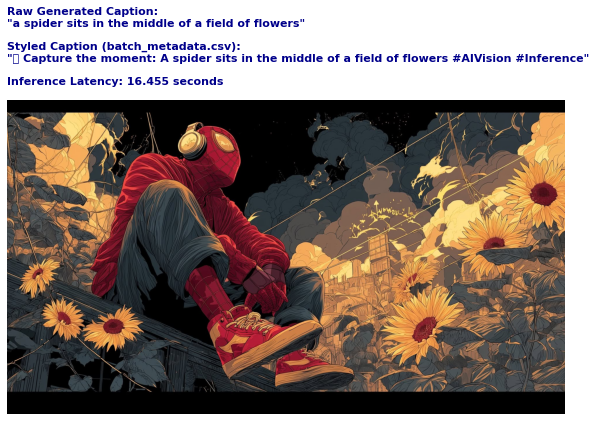

In [21]:
# ==============================================================================
# CELL 9: LOCAL STORAGE IMAGE DISCOVERY & PIPELINE AUTOMATION
# ==============================================================================
import glob

def run_pipeline_on_local_images(style: str = "minimalist"):
    """Scans the data/raw directory and runs captions on all discovered local files."""
    # Find all common image formats inside data/raw
    supported_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
    local_images = []
    
    for ext in supported_extensions:
        # Searches both upper and lower case extensions
        local_images.extend(glob.glob(os.path.join(PipelineConfig.RAW_DATA_DIR, ext)))
        local_images.extend(glob.glob(os.path.join(PipelineConfig.RAW_DATA_DIR, ext.upper())))
        
    if not local_images:
        print(f"⚠️ No images found in '{PipelineConfig.RAW_DATA_DIR}'.")
        print("👉 Drop a few local .jpg or .png files into that folder and re-run this cell!")
        return

    print(f"[LOCAL TASK] Discovered {len(local_images)} local images for processing.")
    
    # Run the batch through our production pipeline engine
    batch_results = pipeline.execute_batch(local_images, style=style)
    
    # Visualize the results in the notebook
    for result in batch_results:
        display_pipeline_output(result)

# Trigger local folder run
run_pipeline_on_local_images(style="social_media")